In [13]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained, ttest_im_sess
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

In [14]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants
sn    = 108

# Representational geometry at session 3
*Compare with model components below

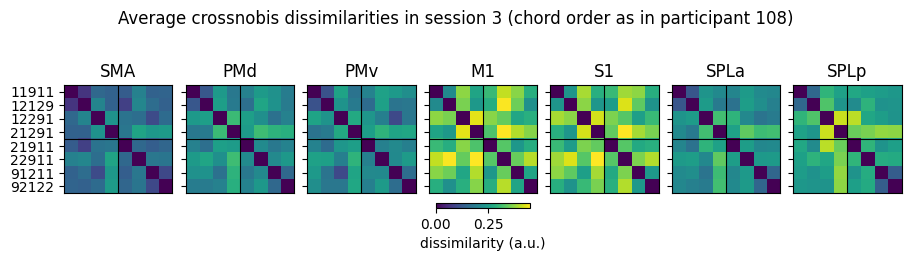

In [15]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 2.5))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for s in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{s}', f'G_obs_raw.within_session.3.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=get_trained_and_untrained(sn))
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([])
    ax.set_yticks(np.arange(8))
    #ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, fraction=.03, label='dissimilarity (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3 (chord order as in participant {sn})')

fig.savefig('figures/crossnobis_example_108.pdf')

plt.show()

# Crossnobis dissimilarities between activity patterns for trained and untrained chords
In M1 and S1, activity patterns for trained chords are more distant among each other compared to untrained chords.

           T  dof     p_val             CI95   roi  session
0  -0.513125   13  0.616472   [-0.02, 0.012]   SMA        3
3  -0.394317   13  0.699739  [-0.019, 0.013]   PMd        3
6  -0.746851   13  0.468447  [-0.037, 0.018]   PMv        3
9   0.040017   13  0.968687  [-0.045, 0.047]    M1        3
12 -0.192370   13  0.850425  [-0.034, 0.029]    S1        3
15 -1.120321   13  0.282848   [-0.05, 0.016]  SPLa        3
18 -0.881864   13  0.393864  [-0.051, 0.022]  SPLp        3
7  -0.186844   13  0.854667  [-0.039, 0.033]   PMv        9
13  1.224805   13  0.242379   [-0.02, 0.071]    S1        9
10  0.778509   13  0.450208  [-0.029, 0.061]    M1        9
4  -0.710323   13  0.490051  [-0.035, 0.018]   PMd        9
1  -0.094600   13  0.926075  [-0.026, 0.024]   SMA        9
16  0.012733   13  0.990034  [-0.031, 0.031]  SPLa        9
19  0.031989   13  0.974967  [-0.033, 0.034]  SPLp        9
5   0.309214   13  0.762059  [-0.011, 0.014]   PMd       23
2  -0.696239   13  0.498539  [-0.017, 0.

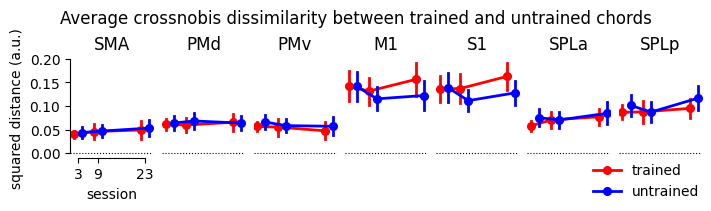

In [16]:
dist            = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist            = dist[(dist.Hem=='L') & (dist.chord.isin(['trained', 'untrained']))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

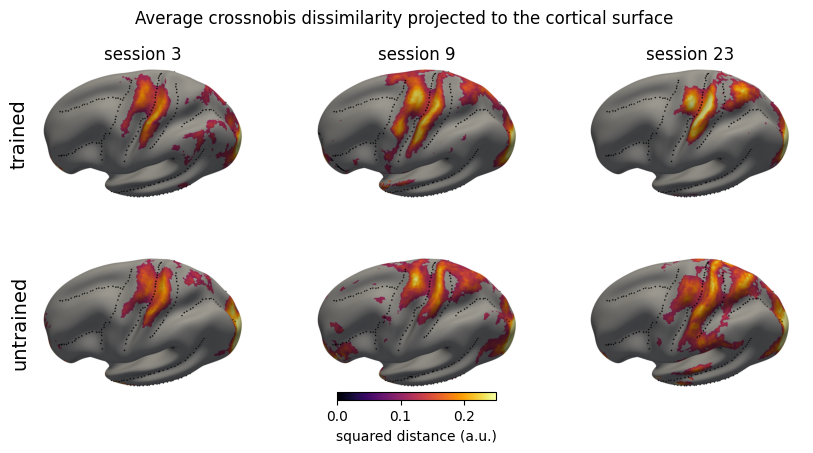

In [17]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('encoding-trained')
    untr_col = cols.index('encoding-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='squared distance (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

# Angle between activity patterns for trained and untrained chords
The angles between activity patterns for trained chords are also wider compared to untrained chords.

           T  dof     p_val              CI95   roi  session
0   0.638414   13  0.534290   [-0.009, 0.016]   SMA        3
3   0.190732   13  0.851682    [-0.01, 0.012]   PMd        3
6   0.617207   13  0.547757    [-0.01, 0.018]   PMv        3
9   0.651453   13  0.526103   [-0.011, 0.021]    M1        3
12  0.376644   13  0.712514    [-0.014, 0.02]    S1        3
15  0.462592   13  0.651304   [-0.012, 0.018]  SPLa        3
18  0.968807   13  0.350322   [-0.008, 0.021]  SPLp        3
7  -0.631727   13  0.538516   [-0.017, 0.009]   PMv        9
13 -1.504436   13  0.156372   [-0.025, 0.005]    S1        9
10  0.155914   13  0.878496   [-0.013, 0.015]    M1        9
4  -0.416667   13  0.683720   [-0.013, 0.009]   PMd        9
1   0.959441   13  0.354842   [-0.005, 0.014]   SMA        9
16 -1.067377   13  0.305223   [-0.018, 0.006]  SPLa        9
19  0.013375   13  0.989532     [-0.01, 0.01]  SPLp        9
5  -1.265810   13  0.227796   [-0.015, 0.004]   PMd       23
2  -0.234140   13  0.818

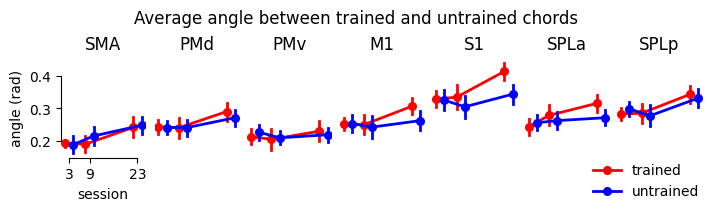

In [18]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average angle between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/angle_mean.pdf')

plt.show()

# Activity vs. dissimilarity
- Activity $a$ for trained and untrained chords was estimated from the cross-validated G-matrix as: $a = \frac{1}{K}\sum_{k=1}^{K}\sqrt{G_{kk}}$; where $K=4$ is the number of chords within the trained and untrained set.

- Dissimilarity $d$ between trained and untrained chords was estimated as the mean off-diagonal crossnobis distance $d = \frac{2}{K(K-1)}\sum_{k<l}\sqrt{D_{kl}}$ over the same conditions, with $D = $ `pcm.G_to_dist(G)`.

- The predicted dissimilarity in session 9 (and 23) if patterns only scaled with activity would be $\hat d_9 = \frac{a_9}{a_3} d_3$; $d_9 - \hat d_9$ (the `residual`) larger than 0 would occur if the patterns separated by more than a change in activity alone can account for.

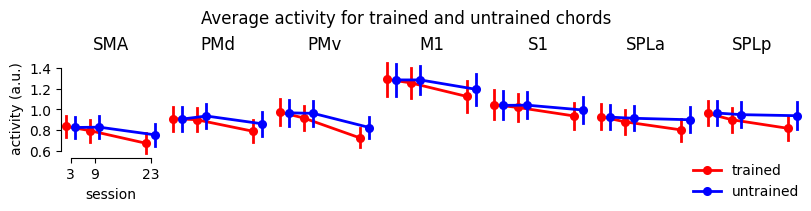

In [19]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='act_target', hue='chord', hue_order=hue_order, palette=palette, estimator='mean', add_zero=False, dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

fig.suptitle('Average activity for trained and untrained chords')

plt.show()

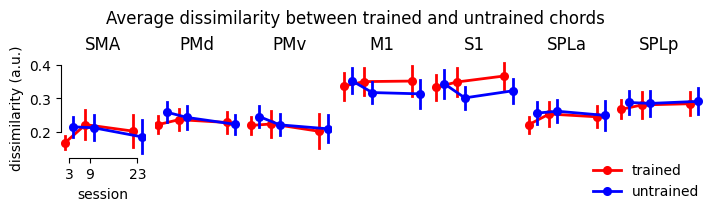

In [20]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois, y='diss_target_observed', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('dissimilarity (a.u.)')

fig.suptitle('Average dissimilarity between trained and untrained chords')

plt.show()

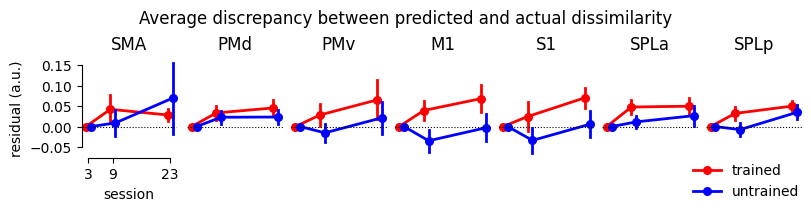

In [21]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('residual (a.u.)')

fig.suptitle('Average discrepancy between predicted and actual dissimilarity')

plt.show()

# Component model

Components and corresponding hypothesis about representational geometry:

- **type**     : trained vs. untrained, geometry reflects which chords are practiced
- **trained**  : trained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *trained* chords)
- **untrained**: untrained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *untrained* chords)
- **finger**   : geometry reflects which fingers are used in each chord
- **pattern**  : geometry reflects which fingers are used in each chord, and in what direction (i.e., flexion or extension)
- **flexion**  : geometry reflects how many fingers in each chord are pressed in flexion direction

*The **finger**, **pattern** and **flexion** components are different in each participant, depending on the assigned trained and untrained chords 

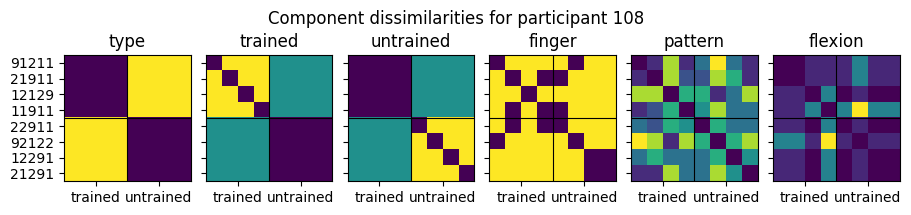

In [22]:
M, comp_names = make_models(sn)
Mc = M[-2]

trained_untrained = get_trained_and_untrained(sn)

fig, axs = plt.subplots(1, Mc.Gc.shape[0], sharex=True, sharey=True, figsize=(9, 2), constrained_layout=True)

for i, G in enumerate(Mc.Gc):
    ax = axs[i]
    d = pcm.G_to_dist(G)
    ax.imshow(d)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)
    ax.set_title(comp_names[i])

fig.suptitle(f'Component dissimilarities for participant {sn}')

fig.savefig('figures/components.pdf')

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.972749   13  0.348431   [-0.027, 0.01]   SMA        3
1  -1.369841   13  0.193933  [-0.048, 0.011]   SMA        9
2  -0.088643   13  0.930717   [-0.02, 0.018]   SMA       23
3  -0.217790   13  0.830974   [-0.025, 0.02]   PMd        3
4  -1.391512   13  0.187424  [-0.069, 0.015]   PMd        9
5   0.556931   13  0.587035   [-0.018, 0.03]   PMd       23
6   0.630438   13  0.539333  [-0.022, 0.041]   PMv        3
7  -0.997211   13  0.336862  [-0.066, 0.024]   PMv        9
8  -0.633551   13  0.537362  [-0.026, 0.014]   PMv       23
9  -0.723033   13  0.482466  [-0.084, 0.042]    M1        3
10 -0.013921   13  0.989104  [-0.044, 0.043]    M1        9
11  2.138782   13  0.052010      [-0.0, 0.1]    M1       23
12 -0.221783   13  0.827929   [-0.04, 0.033]    S1        3
13  0.578760   13  0.572643  [-0.036, 0.062]    S1        9
14  2.722553   13  0.017428     [0.01, 0.09]    S1       23
15 -1.052766   13  0.311623  [-0.054, 0.

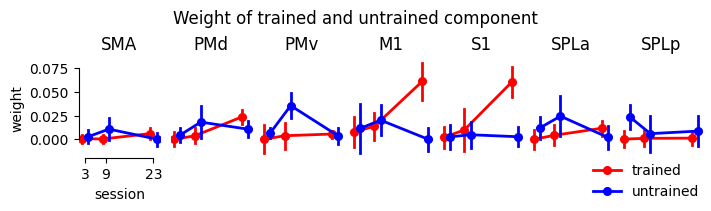

In [23]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'component_model.{atlas}.glm{glm}.tsv'), sep='\t')
N = comp_model.sn.nunique()
hue_order, palette = (['trained', 'untrained'], ['red', 'blue'])
comp_model_tr_untr = comp_model[comp_model.component.isin(hue_order) & (comp_model.Hem==H)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, comp_model_tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', estimator='median', dodge=.3)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of trained and untrained component')

ttest = ttest_im_sess(comp_model_tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/component_model_trained_untrained.pdf')

plt.show()

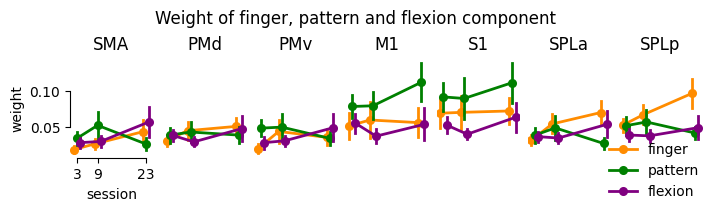

In [24]:
hue_order, palette = ['finger', 'pattern', 'flexion', ], ['darkorange', 'green', 'purple',]
comp_model_repr = comp_model[comp_model.component.isin(hue_order)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', dodge=.3, estimator='mean')
#plot_im_sess(fig, axs, comp_model_repr, rois, y='weight_norm', x='session', hue='component', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of finger, pattern and flexion component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()